In [1]:
import numpy as np
import scipy.io as sio
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr
import seaborn as sns
import pandas as pd
from matplotlib.cm import get_cmap
import networkx as nx
import pingouin as pg  
import scipy.stats as stats


color1='#f0c808'
color2='#e07a5f'
color3='#3d405b'
color4='#81b29a'

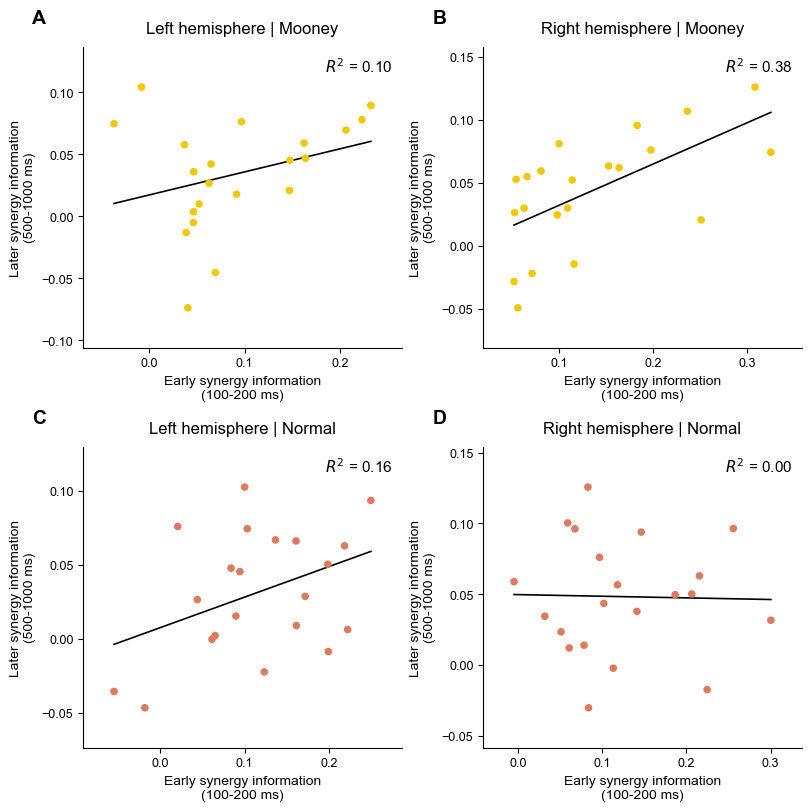

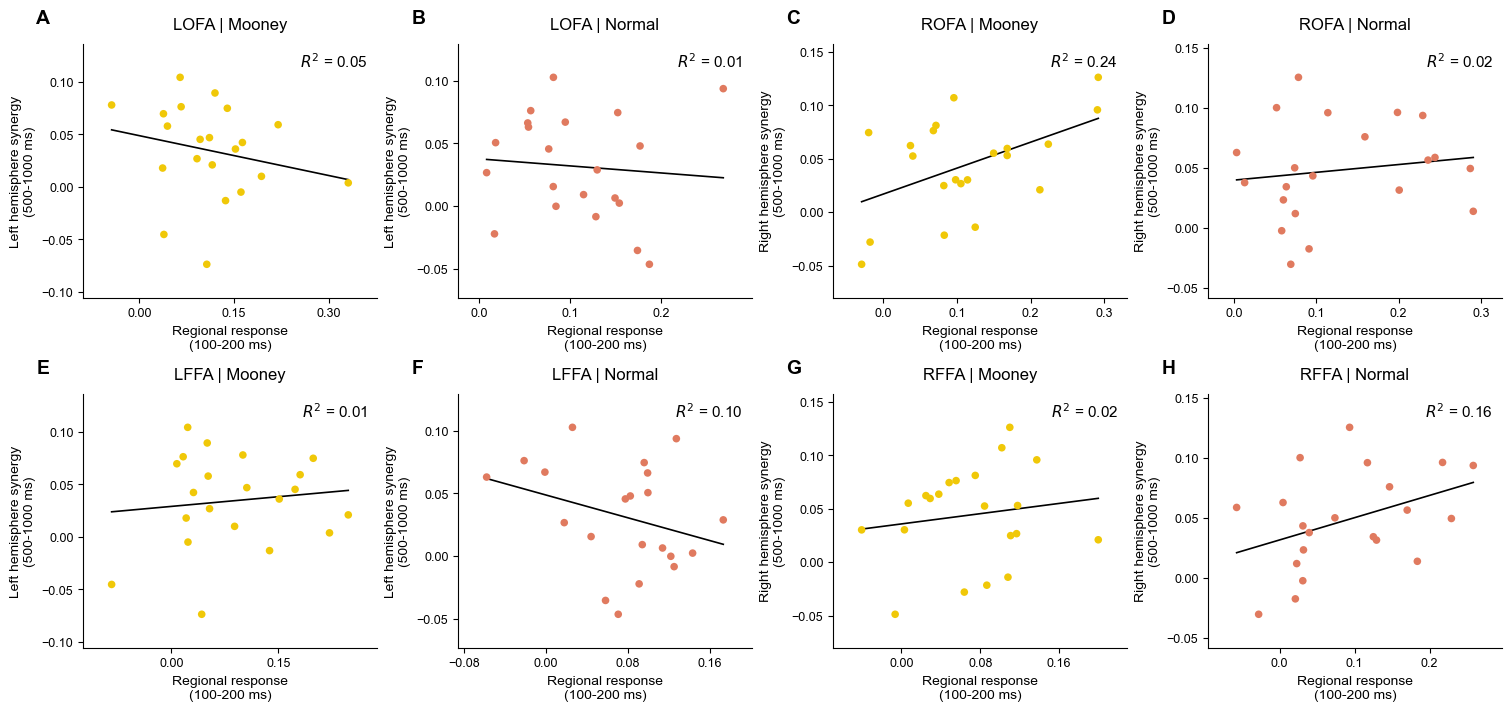

图片已保存至： E:\program2\PIDstudy\MEG_monneyface\output\fig6_fig7_combined


In [5]:
from pathlib import Path
import numpy as np
import scipy.io as sio
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


if 'monney_avg' not in globals() or 'normal_avg' not in globals():
    raise RuntimeError("请先运行原来的预处理代码，生成 monney_avg 和 normal_avg。")

colors = {'Mooney': '#f0c808', 'Normal': '#e07a5f'}

synergy_files = {
    'Left': 'synergy_result_list_LV1LOFA_to_LFFA_50ms_noresample.mat',
    'Right': 'synergy_result_list_RV1ROFA_to_RFFA_50ms_noresample.mat',
}


fs_fig = 1200
nt_fig = 4140
ns_fig = 21

time_fig = np.arange(1/fs_fig, nt_fig/fs_fig + 1e-9, 1/fs_fig)
time_fig -= 1 - (3.5 - time_fig.max())

early_mask = (time_fig > 0.1) & (time_fig < 0.2)
late_mask = (time_fig > 0.5) & (time_fig < 1.0)

synergy_fig = {}

for hemi, filename in synergy_files.items():
    mat = sio.loadmat(filename)
    synergy_fig[hemi] = {}

    for condition, key in [
        ('Mooney', 'Monney_synergy'),
        ('Normal', 'Normal_synergy'),
    ]:
        values = (
            np.asarray(mat[key], dtype=float)
            .reshape(ns_fig, nt_fig).T.copy()
        )


        values -= values[time_fig < 0].mean(axis=0)

        synergy_fig[hemi][condition] = {
            'early': values[early_mask].mean(axis=0),
            'late': values[late_mask].mean(axis=0),
        }



def draw_scatter(ax, x, y, condition, title, xlabel, ylabel, panel):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    if (
        len(x) != ns_fig or len(y) != ns_fig
        or not np.all(np.isfinite(x))
        or not np.all(np.isfinite(y))
    ):
        raise ValueError("每个面板需要 21 组有效且一一对应的被试数据。")

    if np.ptp(x) == 0 or np.ptp(y) == 0:
        raise ValueError("数据没有变化，无法计算相关性。")


    ax.scatter(
        x, y, s=30, color=colors[condition],
        edgecolors='none', zorder=3
    )


    slope, intercept = np.polyfit(x, y, 1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, slope * xx + intercept, color='black', lw=1.2)

    r, _ = pearsonr(x, y)
    ax.text(
        0.97, 0.97, f'$R^2$ = {r*r:.2f}',
        transform=ax.transAxes,
        ha='right', va='top', fontsize=11,
        bbox=dict(
            facecolor='white', alpha=0.8,
            edgecolor='none', pad=2
        )
    )

    ax.text(
        -0.16, 1.08, panel,
        transform=ax.transAxes,
        fontsize=14, fontweight='bold'
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(labelsize=9)
    ax.margins(x=0.12, y=0.18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ========== Figure 6：2 × 2 ==========
# 第一行：Mooney；第二行：Normal
# 第一列：左半球；第二列：右半球
fig6, axes6 = plt.subplots(
    2, 2, figsize=(8, 8), constrained_layout=True
)

for row, condition in enumerate(['Mooney', 'Normal']):
    for col, hemi in enumerate(['Left', 'Right']):
        values = synergy_fig[hemi][condition]

        draw_scatter(
            axes6[row, col],
            values['early'],
            values['late'],
            condition,
            title=f'{hemi} hemisphere | {condition}',
            xlabel='Early synergy information\n(100-200 ms)',
            ylabel='Later synergy information\n(500-1000 ms)',
            panel='ABCD'[row * 2 + col],
        )



fig7, axes7 = plt.subplots(
    2, 4, figsize=(15, 7), constrained_layout=True
)

for row, area in enumerate(['OFA', 'FFA']):
    for hcol, (prefix, hemi) in enumerate([
        ('L', 'Left'),
        ('R', 'Right'),
    ]):
        roi = prefix + area

        for ccol, condition in enumerate(['Mooney', 'Normal']):
            col = hcol * 2 + ccol
            erp = monney_avg if condition == 'Mooney' else normal_avg

            draw_scatter(
                axes7[row, col],
                erp[roi],
                synergy_fig[hemi][condition]['late'],
                condition,
                title=f'{roi} | {condition}',
                xlabel='Regional response\n(100-200 ms)',
                ylabel=f'{hemi} hemisphere synergy\n(500-1000 ms)',
                panel='ABCDEFGH'[row * 4 + col],
            )



out_dir = Path('output/fig6_fig7_combined')
out_dir.mkdir(parents=True, exist_ok=True)

with plt.rc_context({'pdf.fonttype': 42, 'ps.fonttype': 42}):
    for name, fig in [
        ('Figure6_combined', fig6),
        ('Figure7_combined', fig7),
    ]:
        fig.savefig(out_dir / f'{name}.pdf', bbox_inches='tight')
        fig.savefig(
            out_dir / f'{name}.tiff',
            dpi=300,
            bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'},
        )

plt.show()
print('图片已保存至：', out_dir.resolve())

In [4]:
import numpy as np
import pandas as pd

data1 = [
    ("ROFA", "Mooney", 0.4879764773151741, 0.024821329989536147),
    ("RFFA", "Mooney", 0.1497080896740354, 0.5171752320798128),
    ("LOFA", "Mooney", -0.2236733778662731, 0.3297290458385588),
    ("LFFA", "Mooney", 0.11593857440945632, 0.6167529337443989),
]
data2 = [

    ("ROFA", "Normal", 0.14294263611132657, 0.5364946804651669),
    ("RFFA", "Normal", 0.4006449849739331, 0.07188838309250734),
    ("LOFA", "Normal", -0.08752622555955043, 0.705979971419884),
    ("LFFA", "Normal", -0.30843814586388585, 0.17372437608228827),
]

def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)

    order = np.argsort(pvals)
    sorted_p = pvals[order]

    q_sorted = sorted_p * m / np.arange(1, m + 1)

    for i in range(m - 2, -1, -1):
        q_sorted[i] = min(q_sorted[i], q_sorted[i + 1])

    q_sorted = np.minimum(q_sorted, 1)

    qvals = np.empty_like(q_sorted)
    qvals[order] = q_sorted

    return qvals
for data in [data1, data2]:
    df = pd.DataFrame(
        data, columns=["ROI", "Condition", "r", "p_uncorrected"]
    )
    df["p_FDR"] = fdr_bh(df["p_uncorrected"].to_numpy())
    print(df.to_string(index=False))


 ROI Condition         r  p_uncorrected    p_FDR
ROFA    Mooney  0.487976       0.024821 0.099285
RFFA    Mooney  0.149708       0.517175 0.616753
LOFA    Mooney -0.223673       0.329729 0.616753
LFFA    Mooney  0.115939       0.616753 0.616753
 ROI Condition         r  p_uncorrected    p_FDR
ROFA    Normal  0.142943       0.536495 0.705980
RFFA    Normal  0.400645       0.071888 0.287554
LOFA    Normal -0.087526       0.705980 0.705980
LFFA    Normal -0.308438       0.173724 0.347449


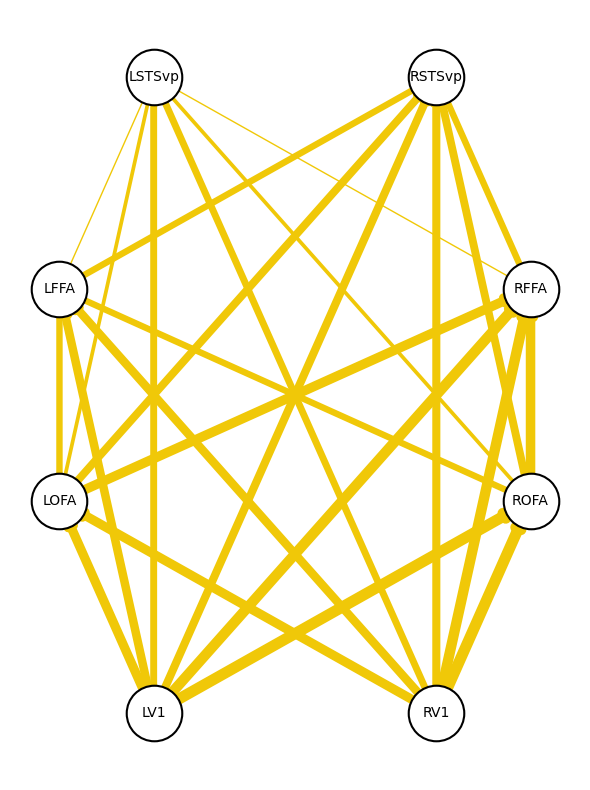

In [20]:
# 设置字体
plt.rcParams["font.family"] = "Arial"

# 脑区位置（已优化）
positions = {
    'LV1': (-1.5, 0),
    'RV1': (1.5, 0),
    'LOFA': (-2.5, 1),
    'ROFA': (2.5, 1),
    'LFFA': (-2.5, 2),
    'RFFA': (2.5, 2),
    'LSTSvp': (-1.5, 3),
    'RSTSvp': (1.5, 3),
}

# Synergy 数据
synergy_data = [
    ('LV1', 'RV1', 'LOFA', 0.353025231),
    ('LV1', 'RV1', 'ROFA', 0.379824911),
    ('LV1', 'RV1', 'LFFA', 0.34254591),
    ('LV1', 'RV1', 'RFFA', 0.369137236),
    ('LV1', 'RV1', 'LSTSvp', 0.32021799),
    ('LV1', 'RV1', 'RSTSvp', 0.336782095),
    ('LOFA', 'ROFA', 'LFFA', 0.31301227),
    ('LOFA', 'ROFA', 'RFFA', 0.357294459),
    ('LOFA', 'ROFA', 'LSTSvp', 0.274858341),
    ('LOFA', 'ROFA', 'RSTSvp', 0.333835487),
    ('LFFA', 'RFFA', 'LSTSvp', 0.241945359),
    ('LFFA', 'RFFA', 'RSTSvp', 0.31388924),
]
# 归一化线宽函数（1 到 8）
all_weights = [x[3] for x in synergy_data]
min_w, max_w = min(all_weights), max(all_weights)

def map_weight(w):
    return 1 + (w - min_w) / (max_w - min_w) * (8 - 1)

# 构建图
G = nx.DiGraph()
G.add_nodes_from(positions.keys())

edges = []
widths = []

for r1, r2, target, synergy in synergy_data:
    width = map_weight(synergy)
    edges.append((r1, target))
    widths.append(width)
    edges.append((r2, target))
    widths.append(width)

# 绘图
fig, ax = plt.subplots(figsize=(6, 8))  # 更紧凑图幅

nx.draw_networkx_nodes(G, positions, node_size=1600, node_color='white', edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, positions, font_size=10)
nx.draw_networkx_edges(
    G, positions,
    edgelist=edges,
    width=widths,
    edge_color=color1,
  
)

plt.axis('off')
plt.tight_layout()

# 保存为高分辨率 PNG 和矢量 PDF
plt.savefig("synergy_brain_network_mooney.pdf", format='pdf')      # 矢量 PDF
plt.savefig("synergy_brain_network_mooney.png", dpi=600)           # 高清 PNG
plt.savefig("synergy_brain_network_mooney.svg", format='svg')      # 矢量 SVG（适合 Illustrator）

plt.show()

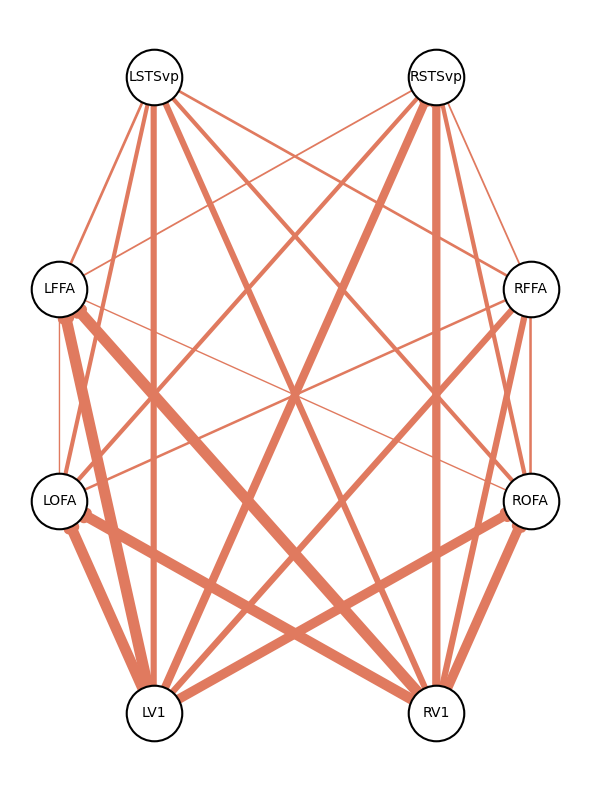

In [21]:
# 设置字体
plt.rcParams["font.family"] = "Arial"

# 脑区位置（已优化）
positions = {
    'LV1': (-1.5, 0),
    'RV1': (1.5, 0),
    'LOFA': (-2.5, 1),
    'ROFA': (2.5, 1),
    'LFFA': (-2.5, 2),
    'RFFA': (2.5, 2),
    'LSTSvp': (-1.5, 3),
    'RSTSvp': (1.5, 3),
}

# Synergy 数据
synergy_data = [
    ('LV1', 'RV1', 'LOFA', 0.361674505),
    ('LV1', 'RV1', 'ROFA', 0.35174392),
    ('LV1', 'RV1', 'LFFA', 0.365521686),
    ('LV1', 'RV1', 'RFFA', 0.323354313),
    ('LV1', 'RV1', 'LSTSvp', 0.322215762),
    ('LV1', 'RV1', 'RSTSvp', 0.340591934),
    ('LOFA', 'ROFA', 'LFFA', 0.280264235),
    ('LOFA', 'ROFA', 'RFFA', 0.290332272),
    ('LOFA', 'ROFA', 'LSTSvp', 0.304244669),
    ('LOFA', 'ROFA', 'RSTSvp', 0.305363492),
    ('LFFA', 'RFFA', 'LSTSvp', 0.291507456),
    ('LFFA', 'RFFA', 'RSTSvp', 0.283712798),
]

# 归一化线宽函数（1 到 8）
all_weights = [x[3] for x in synergy_data]
min_w, max_w = min(all_weights), max(all_weights)

def map_weight(w):
    return 1 + (w - min_w) / (max_w - min_w) * (8 - 1)

# 构建图
G = nx.DiGraph()
G.add_nodes_from(positions.keys())

edges = []
widths = []

for r1, r2, target, synergy in synergy_data:
    width = map_weight(synergy)
    edges.append((r1, target))
    widths.append(width)
    edges.append((r2, target))
    widths.append(width)

# 绘图
fig, ax = plt.subplots(figsize=(6, 8))  # 更紧凑图幅

nx.draw_networkx_nodes(G, positions, node_size=1600, node_color='white', edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, positions, font_size=10)
nx.draw_networkx_edges(
    G, positions,
    edgelist=edges,
    width=widths,
    edge_color=color2,
  
)

plt.axis('off')
plt.tight_layout()

# 保存为高分辨率 PNG 和矢量 PDF
plt.savefig("synergy_brain_network_normal.pdf", format='pdf')      # 矢量 PDF
plt.savefig("synergy_brain_network_normal.png", dpi=600)           # 高清 PNG
plt.savefig("synergy_brain_network_normal.svg", format='svg')      # 矢量 SVG（适合 Illustrator）

plt.show()


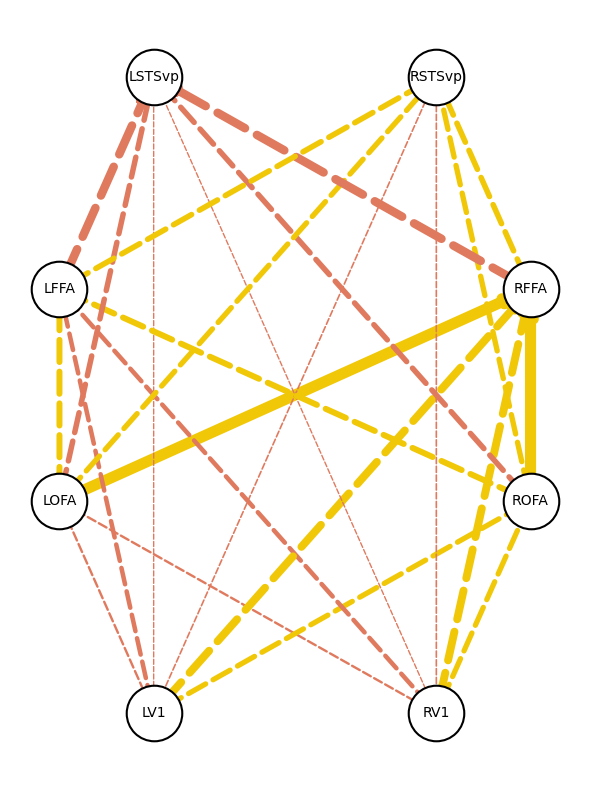

In [4]:
# 设置字体
plt.rcParams["font.family"] = "Arial"

# 脑区位置
positions = {
    'LV1': (-1.5, 0),
    'RV1': (1.5, 0),
    'LOFA': (-2.5, 1),
    'ROFA': (2.5, 1),
    'LFFA': (-2.5, 2),
    'RFFA': (2.5, 2),
    'LSTSvp': (-1.5, 3),
    'RSTSvp': (1.5, 3),
}


synergy_diff_data = [
    ('LV1', 'RV1', 'LOFA',    -0.008649274,1),
    ('LV1', 'RV1', 'ROFA',     0.028080991, 1),
    ('LV1', 'RV1', 'LFFA',    -0.022975776, 1),
    ('LV1', 'RV1', 'RFFA',     0.045782923, 1),
    ('LV1', 'RV1', 'LSTSvp',  -0.001997771, 1),
    ('LV1', 'RV1', 'RSTSvp',  -0.003809838, 1),
    ('LOFA', 'ROFA', 'LFFA',   0.032748035, 1),
    ('LOFA', 'ROFA', 'RFFA',   0.066962187, 0),
    ('LOFA', 'ROFA', 'LSTSvp',-0.029386328, 1),
    ('LOFA', 'ROFA', 'RSTSvp', 0.028471994, 1),
    ('LFFA', 'RFFA', 'LSTSvp',-0.049562097, 1),
    ('LFFA', 'RFFA', 'RSTSvp', 0.030176443, 1),
]
# 提取所有差值用于归一化线宽
all_diffs = [abs(x[3]) for x in synergy_diff_data]
min_diff, max_diff = min(all_diffs), max(all_diffs)

def map_width(d):
    return 1 + (abs(d) - min_diff) / (max_diff - min_diff) * (8 - 1)

# 初始化图
G = nx.DiGraph()
G.add_nodes_from(positions.keys())

edges = []
widths = []
colors = []
styles = []

for src1, src2, tgt, diff, pval in synergy_diff_data:
    for src in (src1, src2):
        edges.append((src, tgt))
        widths.append(map_width(diff))
        # 根据符号选择颜色
        if diff>0:
            colors.append(color1)
        elif diff<0:
            colors.append(color2)
   
        # 显著性控制线型
        styles.append('solid' if pval < 0.05 else 'dashed')

# 绘图
fig, ax = plt.subplots(figsize=(6, 8))

# 节点
nx.draw_networkx_nodes(G, positions, node_size=1600, node_color='white', edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, positions, font_size=10)

# 边（需要分别处理不同线型）
for style in set(styles):
    idxs = [i for i, s in enumerate(styles) if s == style]
    nx.draw_networkx_edges(
        G, positions,
        edgelist=[edges[i] for i in idxs],
        width=[widths[i] for i in idxs],
        edge_color=[colors[i] for i in idxs],
        style=style
    )

plt.axis('off')
plt.tight_layout()

# 保存
plt.savefig("synergy_diff_network.pdf", format='pdf')
plt.savefig("synergy_diff_network.png", dpi=600)
plt.savefig("synergy_diff_network.svg", format='svg')

plt.show()